# RecSys Attention Mask Analysis

## what is the RecSys attention mask?

The Phoenix recommendation model uses a **custom attention mask** (`make_recsys_attn_mask`) to enforce **candidate isolation** during ranking. This notebook analyzes and visualizes how this mask works end-to-end.

## why candidate isolation matters

In a standard causal transformer every token attends to all prior tokens. For batched candidate ranking that would be problematic: candidate C2 could "see" C1, so its representation would depend on what else is in the batch — meaning each candidate wouldn't be scored independently on user+history context alone.

## sequence layout

```
[ user | history_1 … history_S | candidate_1 … candidate_C ]
```

- Positions `0 … candidate_start_offset-1` — **user + history** (context prefix)  
- Positions `candidate_start_offset …` — **candidates** to rank

The mask guarantees:
1. **User + history attend causally** to each other  
2. **Each candidate attends to ALL user+history** (full context, not just causal prefix)  
3. **Each candidate attends only to itself** among other candidates (no cross-candidate leakage)

In [1]:
import sys
sys.path.insert(0, 'phoenix')

import numpy as np
import jax
import jax.numpy as jnp
import jax.tree_util as jtu
import haiku as hk
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from grok import make_recsys_attn_mask, Transformer, TransformerConfig
from runners import create_example_batch

print('JAX devices:', jax.devices())

JAX devices: [CpuDevice(id=0)]


### mask design: three attention regions

Given `seq_len = S + C` and `candidate_start_offset = S`:

#### region 1 — causal block (upper-left, rows $0 \ldots S-1$, cols $0 \ldots S-1$)
The user token and history tokens attend **causally** to each other, exactly like a standard language model. Row $i$ in this block can see columns $0 \ldots i$.

#### region 2 — context block (lower-left, rows $S \ldots S+C-1$, cols $0 \ldots S-1$)
Every candidate token sees the **entire** user+history prefix. This gives each candidate the full context it needs to be scored, without any causal restriction.

#### region 3 — self-attention only (lower-right diagonal, rows $S \ldots S+C-1$, cols $S \ldots S+C-1$)
Within the candidate block, only the **diagonal** is 1. Each candidate attends to itself and nothing else. Off-diagonal entries are 0, so candidates are completely blind to one another.

The mask is constructed by:
1. Starting from a standard lower-triangular causal mask
2. Zeroing out the entire bottom-right candidate-to-candidate block
3. Restoring the diagonal of that block (self-attention)

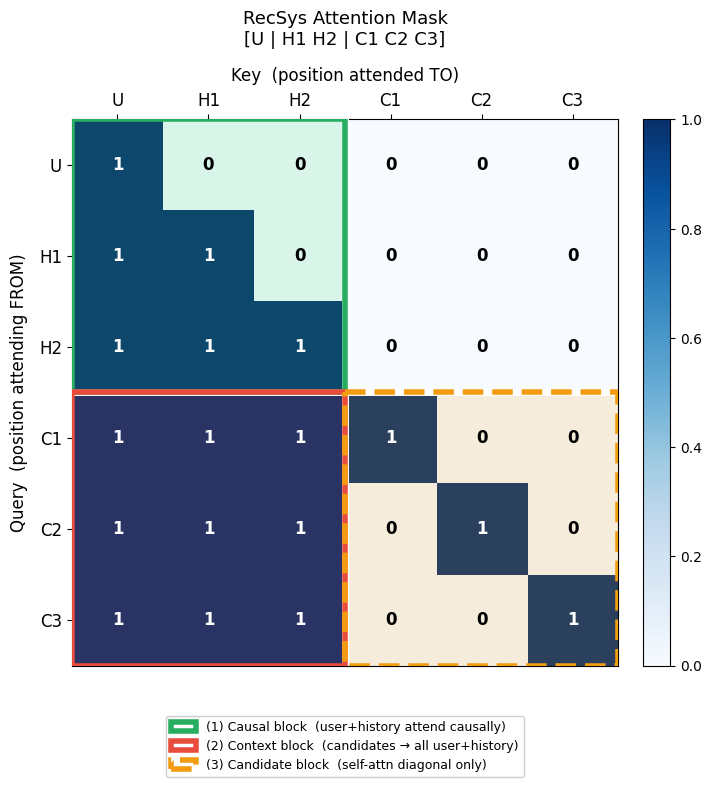

Mask shape (squeezed): (6, 6)


In [2]:
seq_len = 6
candidate_start_offset = 3
labels = ['U', 'H1', 'H2', 'C1', 'C2', 'C3']

mask_raw = make_recsys_attn_mask(seq_len, candidate_start_offset)
mask = np.array(mask_raw).squeeze()  # [seq_len, seq_len]

fig, ax = plt.subplots(figsize=(7.5, 7.5))
im = ax.imshow(mask, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')

ax.set_xticks(range(seq_len))
ax.set_xticklabels(labels, fontsize=12)
ax.set_yticks(range(seq_len))
ax.set_yticklabels(labels, fontsize=12)
ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Key  (position attended TO)', fontsize=12, labelpad=8)
ax.set_ylabel('Query  (position attending FROM)', fontsize=12, labelpad=8)

cso = candidate_start_offset
n_cand = seq_len - cso

# Layer 1: Subtle colored fills so each region reads as a distinct zone
ax.add_patch(mpatches.Rectangle((-0.5, -0.5), cso, cso,
    facecolor='#2ecc71', alpha=0.15, zorder=2))
ax.add_patch(mpatches.Rectangle((-0.5, cso - 0.5), cso, n_cand,
    facecolor='#e74c3c', alpha=0.15, zorder=2))
ax.add_patch(mpatches.Rectangle((cso - 0.5, cso - 0.5), n_cand, n_cand,
    facecolor='#f39c12', alpha=0.15, zorder=2))

# Layer 2: Thick white dividing lines — the strongest visual cue for region boundaries
ax.axhline(cso - 0.5, color='white', linewidth=5, zorder=3)
ax.axvline(cso - 0.5, color='white', linewidth=5, zorder=3)

# Layer 3: Colored region borders on top of dividing lines
rect1 = mpatches.Rectangle((-0.5, -0.5), cso, cso,
    linewidth=4, edgecolor='#27ae60', facecolor='none', zorder=4,
    label='(1) Causal block  (user+history attend causally)')
rect2 = mpatches.Rectangle((-0.5, cso - 0.5), cso, n_cand,
    linewidth=4, edgecolor='#e74c3c', facecolor='none', zorder=4,
    label='(2) Context block  (candidates → all user+history)')
rect3 = mpatches.Rectangle((cso - 0.5, cso - 0.5), n_cand, n_cand,
    linewidth=4, edgecolor='#f39c12', facecolor='none', zorder=4,
    linestyle='--', label='(3) Candidate block  (self-attn diagonal only)')
for r in (rect1, rect2, rect3):
    ax.add_patch(r)

# Layer 4: Value annotations on top of everything
for i in range(seq_len):
    for j in range(seq_len):
        color = 'white' if mask[i, j] > 0.5 else 'black'
        ax.text(j, i, f'{mask[i, j]:.0f}', ha='center', va='center',
                fontsize=12, fontweight='bold', color=color, zorder=5)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08),
          fontsize=9, framealpha=0.95, ncol=1)
ax.set_title('RecSys Attention Mask\n[U | H1 H2 | C1 C2 C3]', fontsize=13, pad=16)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()
print(f'Mask shape (squeezed): {mask.shape}')

In [3]:
mask

array([[1., 0., 0., 0., 0., 0.],
       [1., 1., 0., 0., 0., 0.],
       [1., 1., 1., 0., 0., 0.],
       [1., 1., 1., 1., 0., 0.],
       [1., 1., 1., 0., 1., 0.],
       [1., 1., 1., 0., 0., 1.]], dtype=float32)

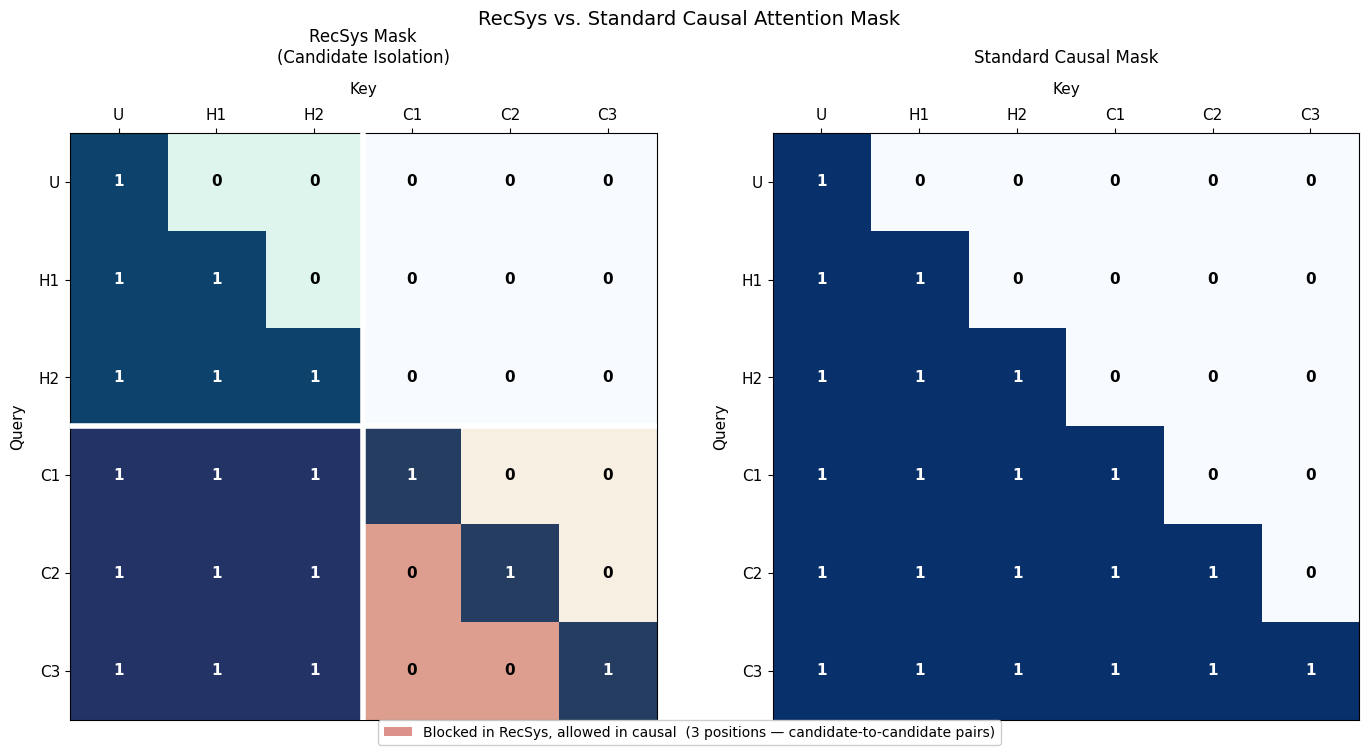

Positions masked in RecSys that causal would allow: 3
  → these are the candidate-to-other-candidate attention pairs


In [4]:
recsys_mask = np.array(make_recsys_attn_mask(seq_len, candidate_start_offset)).squeeze()
causal_mask = np.tril(np.ones((seq_len, seq_len)))
diff = causal_mask - recsys_mask  # > 0 where causal allows but RecSys blocks

fig, axes = plt.subplots(1, 2, figsize=(14, 7), constrained_layout=True)

for ax, m, title in zip(axes,
                         [recsys_mask, causal_mask],
                         ['RecSys Mask\n(Candidate Isolation)', 'Standard Causal Mask']):
    ax.imshow(m, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(range(seq_len))
    ax.set_xticklabels(labels, fontsize=11)
    ax.set_yticks(range(seq_len))
    ax.set_yticklabels(labels, fontsize=11)
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    ax.set_xlabel('Key', fontsize=11, labelpad=10)
    ax.set_ylabel('Query', fontsize=11, labelpad=10)
    ax.set_title(title, fontsize=12, pad=14)

# Region fills + white dividing lines on the RecSys subplot (matches Cell 4 style)
cso = candidate_start_offset
n_cand = seq_len - cso
ax_r = axes[0]
ax_r.add_patch(mpatches.Rectangle((-0.5, -0.5), cso, cso,
    facecolor='#2ecc71', alpha=0.12, zorder=2))
ax_r.add_patch(mpatches.Rectangle((-0.5, cso - 0.5), cso, n_cand,
    facecolor='#e74c3c', alpha=0.12, zorder=2))
ax_r.add_patch(mpatches.Rectangle((cso - 0.5, cso - 0.5), n_cand, n_cand,
    facecolor='#f39c12', alpha=0.12, zorder=2))
ax_r.axhline(cso - 0.5, color='white', linewidth=4, zorder=3)
ax_r.axvline(cso - 0.5, color='white', linewidth=4, zorder=3)

# Highlight the candidate-to-candidate positions that RecSys blocks
for i in range(seq_len):
    for j in range(seq_len):
        if diff[i, j] > 0:
            axes[0].add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1,
                facecolor='#c0392b', alpha=0.45, zorder=2))

# Value annotations drawn last so they sit above all patches
for ax, m in zip(axes, [recsys_mask, causal_mask]):
    for i in range(seq_len):
        for j in range(seq_len):
            c = 'white' if m[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{m[i, j]:.0f}', ha='center', va='center',
                    fontsize=11, fontweight='bold', color=c, zorder=5)

# Figure-level legend below both subplots — no more overlap
red_patch = mpatches.Patch(facecolor='#c0392b', alpha=0.55,
    label=f'Blocked in RecSys, allowed in causal  '
          f'({int(diff.sum())} positions — candidate-to-candidate pairs)')
fig.legend(handles=[red_patch], loc='lower center', fontsize=10,
           framealpha=0.95, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('RecSys vs. Standard Causal Attention Mask', fontsize=14, y=1.02)
plt.show()

print(f'Positions masked in RecSys that causal would allow: {int(diff.sum())}')
print(f'  → these are the candidate-to-other-candidate attention pairs')

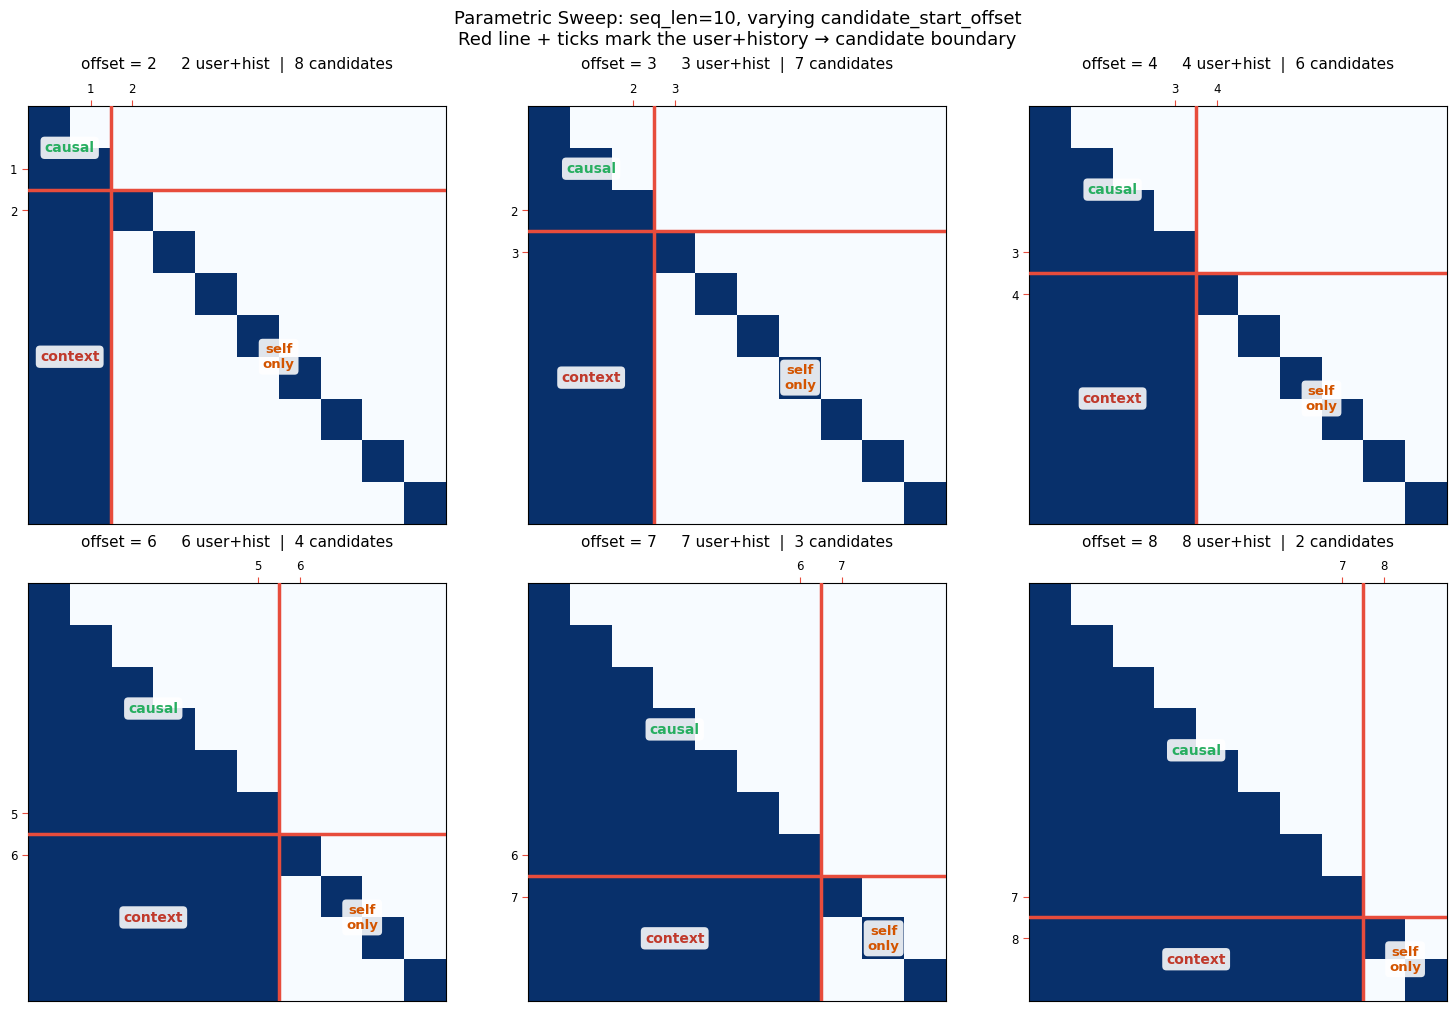

In [5]:
seq_len_sweep = 10
offsets = [2, 3, 4, 6, 7, 8]

fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)

# White pill background for region labels so they're readable on any background
lbl_bbox = dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='none', alpha=0.88)

for ax, offset in zip(axes.flat, offsets):
    m = np.array(make_recsys_attn_mask(seq_len_sweep, offset)).squeeze()
    n_hist  = offset
    n_cand  = seq_len_sweep - offset

    ax.imshow(m, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')

    # Tick marks at the boundary only — makes offset visually obvious
    ax.set_xticks([offset - 1, offset])
    ax.set_xticklabels([f'{offset-1}', f'{offset}'], fontsize=8.5)
    ax.set_yticks([offset - 1, offset])
    ax.set_yticklabels([f'{offset-1}', f'{offset}'], fontsize=8.5)
    ax.xaxis.tick_top()
    ax.tick_params(length=4, color='#e74c3c')  # red ticks at the boundary

    ax.set_title(f'offset = {offset}     {n_hist} user+hist  |  {n_cand} candidates',
                 fontsize=11, pad=10)

    # Thick red dividing lines
    ax.axhline(offset - 0.5, color='#e74c3c', linewidth=2.5, zorder=3)
    ax.axvline(offset - 0.5, color='#e74c3c', linewidth=2.5, zorder=3)

    # Region labels — readable at every offset thanks to white background box
    cx, cy = offset / 2 - 0.5, offset / 2 - 0.5          # causal block center
    ctx_x,  ctx_y  = offset / 2 - 0.5, offset + n_cand / 2 - 0.5   # context block center
    sa_x,   sa_y   = offset + n_cand / 2 - 0.5, offset + n_cand / 2 - 0.5  # self-attn center

    if n_hist >= 1:
        ax.text(cx, cy, 'causal', ha='center', va='center',
                fontsize=10, fontweight='bold', color='#27ae60', zorder=4, bbox=lbl_bbox)
    if n_cand >= 1 and n_hist >= 1:
        ax.text(ctx_x, ctx_y, 'context', ha='center', va='center',
                fontsize=10, fontweight='bold', color='#c0392b', zorder=4, bbox=lbl_bbox)
    if n_cand >= 2:
        ax.text(sa_x, sa_y, 'self\nonly', ha='center', va='center',
                fontsize=9.5, fontweight='bold', color='#d35400', zorder=4, bbox=lbl_bbox)

fig.suptitle(
    'Parametric Sweep: seq_len=10, varying candidate_start_offset\n'
    'Red line + ticks mark the user+history → candidate boundary',
    fontsize=13)
plt.show()

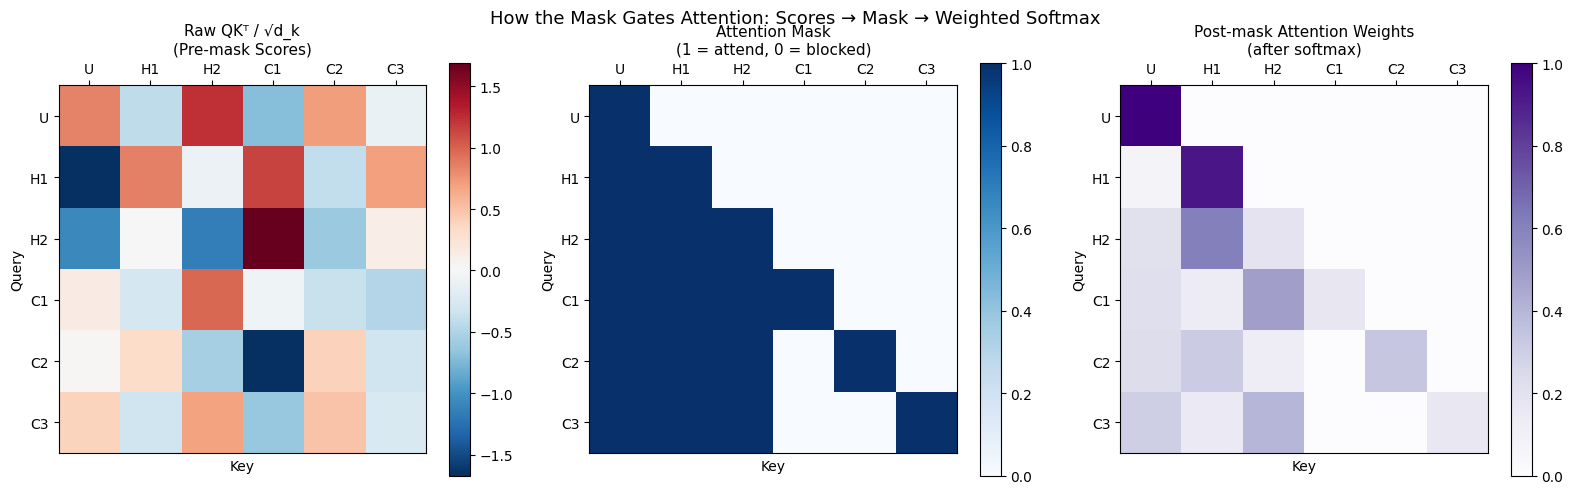

Candidate rows — sum of attention weights (must be 1.0):
  C1: sum = 1.000000, non-zero positions = 4
  C2: sum = 1.000000, non-zero positions = 4
  C3: sum = 1.000000, non-zero positions = 4


In [6]:
# Toy attention weight computation — no model needed
np.random.seed(42)
seq_len_toy = 6
cso_toy = 3
d_k = 8
labels_toy = ['U', 'H1', 'H2', 'C1', 'C2', 'C3']

Q = np.random.randn(seq_len_toy, d_k).astype(np.float32)
K = np.random.randn(seq_len_toy, d_k).astype(np.float32)

scores = Q @ K.T / np.sqrt(d_k)  # [seq_len, seq_len]
mask_toy = np.array(make_recsys_attn_mask(seq_len_toy, cso_toy)).squeeze()

# Apply mask: add -1e9 to blocked positions so they vanish after softmax
scores_masked = scores + (1.0 - mask_toy) * (-1e9)

def softmax(x, axis=-1):
    x_shift = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x_shift)
    return e / np.sum(e, axis=axis, keepdims=True)

attn_weights = softmax(scores_masked, axis=-1)  # [seq_len, seq_len]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

im0 = axes[0].imshow(scores, cmap='RdBu_r', interpolation='nearest')
axes[0].set_title('Raw QK\u1d40 / \u221ad_k\n(Pre-mask Scores)', fontsize=11)
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(mask_toy, cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
axes[1].set_title('Attention Mask\n(1 = attend, 0 = blocked)', fontsize=11)
plt.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(attn_weights, cmap='Purples', vmin=0, vmax=1, interpolation='nearest')
axes[2].set_title('Post-mask Attention Weights\n(after softmax)', fontsize=11)
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xticks(range(seq_len_toy))
    ax.set_xticklabels(labels_toy)
    ax.set_yticks(range(seq_len_toy))
    ax.set_yticklabels(labels_toy)
    ax.xaxis.tick_top()
    ax.set_xlabel('Key', fontsize=10, labelpad=4)
    ax.set_ylabel('Query', fontsize=10)

plt.suptitle('How the Mask Gates Attention: Scores \u2192 Mask \u2192 Weighted Softmax', fontsize=13)
plt.tight_layout()
plt.show()

print('Candidate rows — sum of attention weights (must be 1.0):')
for i, lbl in enumerate(labels_toy[cso_toy:], start=cso_toy):
    print(f'  {lbl}: sum = {attn_weights[i].sum():.6f}, '
          f'non-zero positions = {(attn_weights[i] > 1e-6).sum()}')

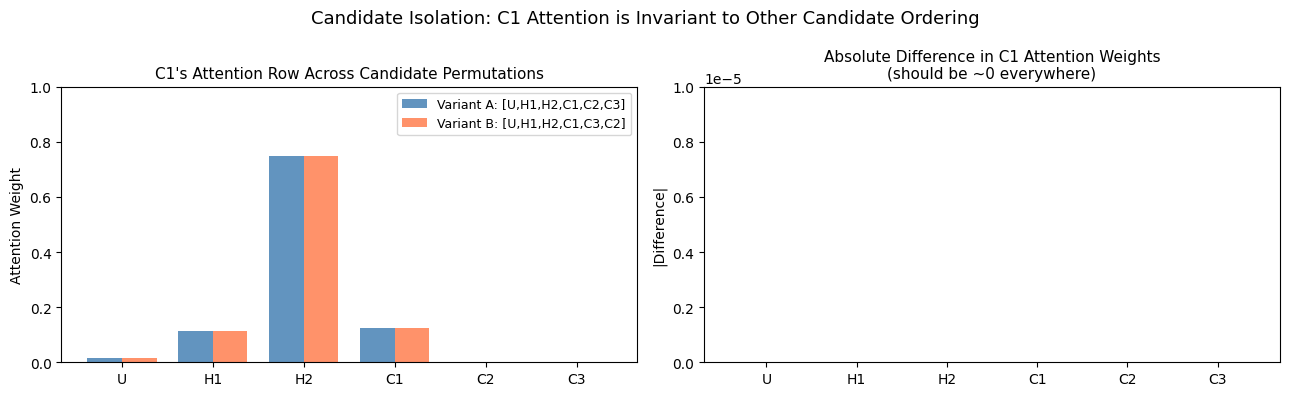

Max |difference| in C1 attention weights: 0.00e+00
C1 attention in Variant A: [0.0141 0.1127 0.7503 0.123  0.     0.    ]
C1 attention in Variant B: [0.0141 0.1127 0.7503 0.123  0.     0.    ]


In [7]:
# Candidate isolation experiment
# Demonstrate that C1's attention row is invariant to permutations of other candidates.
np.random.seed(0)
seq_len_iso = 6
cso_iso = 3
d_k_iso = 8
labels_iso = ['U', 'H1', 'H2', 'C1', 'C2', 'C3']

# Shared user+history Q/K (positions 0-2), identical in both variants
Q_ctx = np.random.randn(cso_iso, d_k_iso).astype(np.float32)
K_ctx = np.random.randn(cso_iso, d_k_iso).astype(np.float32)

# C1 Q/K (position 3), identical in both variants
Q_c1 = np.random.randn(1, d_k_iso).astype(np.float32)
K_c1 = np.random.randn(1, d_k_iso).astype(np.float32)

# C2, C3 in variant A
Q_c2a = np.random.randn(1, d_k_iso).astype(np.float32)
K_c2a = np.random.randn(1, d_k_iso).astype(np.float32)
Q_c3a = np.random.randn(1, d_k_iso).astype(np.float32)
K_c3a = np.random.randn(1, d_k_iso).astype(np.float32)

# Variant B: swap C2 and C3 positions — completely different candidates in positions 4 & 5
Q_c2b, K_c2b = Q_c3a, K_c3a  # position 4 gets C3's vectors
Q_c3b, K_c3b = Q_c2a, K_c2a  # position 5 gets C2's vectors

Q_A = np.concatenate([Q_ctx, Q_c1, Q_c2a, Q_c3a], axis=0)  # [6, d_k]
K_A = np.concatenate([K_ctx, K_c1, K_c2a, K_c3a], axis=0)
Q_B = np.concatenate([Q_ctx, Q_c1, Q_c2b, Q_c3b], axis=0)
K_B = np.concatenate([K_ctx, K_c1, K_c2b, K_c3b], axis=0)

mask_iso = np.array(make_recsys_attn_mask(seq_len_iso, cso_iso)).squeeze()

def compute_attn(Q, K, mask):
    scores = Q @ K.T / np.sqrt(d_k_iso)
    scores_m = scores + (1.0 - mask) * (-1e9)
    return softmax(scores_m, axis=-1)

attn_A = compute_attn(Q_A, K_A, mask_iso)
attn_B = compute_attn(Q_B, K_B, mask_iso)

# Row index 3 = C1's attention weights across all positions
c1_A = attn_A[cso_iso]   # attention row of C1 in variant A
c1_B = attn_B[cso_iso]   # attention row of C1 in variant B

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(seq_len_iso)
w = 0.38

axes[0].bar(x - w/2, c1_A, w, label='Variant A: [U,H1,H2,C1,C2,C3]',
            color='steelblue', alpha=0.85)
axes[0].bar(x + w/2, c1_B, w, label='Variant B: [U,H1,H2,C1,C3,C2]',
            color='coral', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_iso)
axes[0].set_ylabel('Attention Weight')
axes[0].set_ylim(0, 1)
axes[0].legend(fontsize=9)
axes[0].set_title("C1's Attention Row Across Candidate Permutations", fontsize=11)

diff_iso = np.abs(c1_A - c1_B)
axes[1].bar(x, diff_iso, color='gray', alpha=0.85)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_iso)
axes[1].set_ylabel('|Difference|')
axes[1].set_title('Absolute Difference in C1 Attention Weights\n(should be ~0 everywhere)', fontsize=11)
axes[1].set_ylim(0, max(diff_iso.max() * 10, 1e-5))

plt.suptitle('Candidate Isolation: C1 Attention is Invariant to Other Candidate Ordering',
             fontsize=13)
plt.tight_layout()
plt.show()

print(f'Max |difference| in C1 attention weights: {diff_iso.max():.2e}')
print(f'C1 attention in Variant A: {np.round(c1_A, 4)}')
print(f'C1 attention in Variant B: {np.round(c1_B, 4)}')

In [8]:
# Sample input generation via create_example_batch
batch_size = 2
emb_size = 32
history_len = 4
num_candidates = 3
num_actions = 5

batch, embeddings = create_example_batch(
    batch_size=batch_size,
    emb_size=emb_size,
    history_len=history_len,
    num_candidates=num_candidates,
    num_actions=num_actions,
)

candidate_start_offset = 1 + history_len  # 1 user token + history tokens
seq_len_full = 1 + history_len + num_candidates  # = 8

print('=== RecsysBatch (hash indices) ===')
print(f'  user_hashes:              {np.array(batch.user_hashes).shape}        [B, num_user_hashes]')
print(f'  history_post_hashes:      {np.array(batch.history_post_hashes).shape}  [B, history_len, num_item_hashes]')
print(f'  history_author_hashes:    {np.array(batch.history_author_hashes).shape}  [B, history_len, num_author_hashes]')
print(f'  history_actions:          {np.array(batch.history_actions).shape}    [B, history_len, num_actions]')
print(f'  history_product_surface:  {np.array(batch.history_product_surface).shape}        [B, history_len]')
print(f'  candidate_post_hashes:    {np.array(batch.candidate_post_hashes).shape}    [B, num_candidates, num_item_hashes]')
print(f'  candidate_author_hashes:  {np.array(batch.candidate_author_hashes).shape}    [B, num_candidates, num_author_hashes]')
print(f'  candidate_product_surface:{np.array(batch.candidate_product_surface).shape}          [B, num_candidates]')

print('\n=== RecsysEmbeddings (float arrays) ===')
print(f'  user_embeddings:             {np.array(embeddings.user_embeddings).shape}      [B, num_user_hashes, D]')
print(f'  history_post_embeddings:     {np.array(embeddings.history_post_embeddings).shape}  [B, history_len, num_item_hashes, D]')
print(f'  candidate_post_embeddings:   {np.array(embeddings.candidate_post_embeddings).shape}  [B, num_candidates, num_item_hashes, D]')
print(f'  history_author_embeddings:   {np.array(embeddings.history_author_embeddings).shape}  [B, history_len, num_author_hashes, D]')
print(f'  candidate_author_embeddings: {np.array(embeddings.candidate_author_embeddings).shape}  [B, num_candidates, num_author_hashes, D]')

print(f'\n=== Sequence layout for Transformer input ===')
print(f'  Total seq_len:           {seq_len_full}  (= 1 + {history_len} + {num_candidates})')
print(f'  Position 0:              user token')
print(f'  Positions 1-{history_len}:          history tokens ({history_len})')
print(f'  Positions {candidate_start_offset}-{seq_len_full-1}:          candidate tokens ({num_candidates})')
print(f'  candidate_start_offset:  {candidate_start_offset}')

=== RecsysBatch (hash indices) ===
  user_hashes:              (2, 2)        [B, num_user_hashes]
  history_post_hashes:      (2, 4, 2)  [B, history_len, num_item_hashes]
  history_author_hashes:    (2, 4, 2)  [B, history_len, num_author_hashes]
  history_actions:          (2, 4, 5)    [B, history_len, num_actions]
  history_product_surface:  (2, 4)        [B, history_len]
  candidate_post_hashes:    (2, 3, 2)    [B, num_candidates, num_item_hashes]
  candidate_author_hashes:  (2, 3, 2)    [B, num_candidates, num_author_hashes]
  candidate_product_surface:(2, 3)          [B, num_candidates]

=== RecsysEmbeddings (float arrays) ===
  user_embeddings:             (2, 2, 32)      [B, num_user_hashes, D]
  history_post_embeddings:     (2, 4, 2, 32)  [B, history_len, num_item_hashes, D]
  candidate_post_embeddings:   (2, 3, 2, 32)  [B, num_candidates, num_item_hashes, D]
  history_author_embeddings:   (2, 4, 2, 32)  [B, history_len, num_author_hashes, D]
  candidate_author_embeddings: (2, 3

Input embeddings shape: (2, 8, 32)  [B, T, D]


W0315 18:39:44.757684  293195 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Output (recsys mask) shape: (2, 8, 32)  [B, T, D]
Output (causal mask)  shape: (2, 8, 32)  [B, T, D]

L2 difference in candidate representations [B=2, C=3]:
[[0.     0.0019 0.0024]
 [0.     0.0011 0.0032]]
Mean L2 difference: 0.0014
Mean L2 norm (recsys): 3.7776
Mean L2 norm (causal): 3.7775

Non-zero differences confirm the mask changes candidate representations.


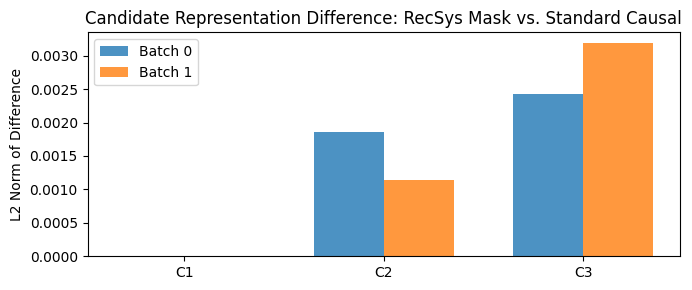

In [9]:
# Random-initialized Transformer forward pass
# Build a flat [B, T, D] embedding by averaging over hash dimensions.
user_emb  = np.array(embeddings.user_embeddings).mean(axis=1, keepdims=True)  # [B, 1, D]
hist_emb  = np.array(embeddings.history_post_embeddings).mean(axis=2)          # [B, S, D]
cand_emb  = np.array(embeddings.candidate_post_embeddings).mean(axis=2)        # [B, C, D]

# Concatenate: [B, 1+S+C, D] = [B, 8, 32]
seq_emb = np.concatenate([user_emb, hist_emb, cand_emb], axis=1)
seq_emb_jax = jnp.array(seq_emb)
pad_mask = jnp.ones((batch_size, seq_len_full), dtype=jnp.float32)  # no padding

cso = candidate_start_offset  # = 5

print(f'Input embeddings shape: {seq_emb_jax.shape}  [B, T, D]')

# Define Transformer forward function
def run_transformer(x, mask, candidate_start_offset=None):
    model = Transformer(
        num_q_heads=2,
        num_kv_heads=2,
        key_size=16,
        widening_factor=4.0,
        attn_output_multiplier=1.0,
        num_layers=2,
    )
    return model(x, mask, candidate_start_offset)

transformed = hk.transform(run_transformer)
rng_init = jax.random.PRNGKey(42)

# Init params (zero-initialized weights by design in this codebase)
params = transformed.init(rng_init, seq_emb_jax, pad_mask, candidate_start_offset=cso)

# The Linear layers in grok.py use Constant(0) init — replace with small random values
# so attention and FFN layers produce non-trivial outputs for a meaningful comparison.
rng_rand = jax.random.PRNGKey(7)
leaves, treedef = jtu.tree_flatten(params)
leaf_rngs = jax.random.split(rng_rand, len(leaves))
params_rand = treedef.unflatten([
    jax.random.normal(r, leaf.shape, leaf.dtype) * 0.02
    for r, leaf in zip(leaf_rngs, leaves)
])

rng_apply = jax.random.PRNGKey(0)

# Forward pass WITH RecSys mask (candidate isolation)
out_masked  = transformed.apply(params_rand, rng_apply, seq_emb_jax, pad_mask,
                                candidate_start_offset=cso)

# Forward pass WITHOUT mask (standard causal)
out_causal  = transformed.apply(params_rand, rng_apply, seq_emb_jax, pad_mask)

print(f'Output (recsys mask) shape: {out_masked.embeddings.shape}  [B, T, D]')
print(f'Output (causal mask)  shape: {out_causal.embeddings.shape}  [B, T, D]')

# Compare candidate token representations
cands_masked = out_masked.embeddings[:, cso:, :]   # [B, C, D]
cands_causal = out_causal.embeddings[:, cso:, :]   # [B, C, D]

diff_norm = jnp.linalg.norm(cands_masked - cands_causal, axis=-1)  # [B, C]
print(f'\nL2 difference in candidate representations [B={batch_size}, C={num_candidates}]:')
print(np.array(diff_norm).round(4))
print(f'Mean L2 difference: {float(jnp.mean(diff_norm)):.4f}')
print(f'Mean L2 norm (recsys): {float(jnp.mean(jnp.linalg.norm(cands_masked, axis=-1))):.4f}')
print(f'Mean L2 norm (causal): {float(jnp.mean(jnp.linalg.norm(cands_causal, axis=-1))):.4f}')
print('\nNon-zero differences confirm the mask changes candidate representations.')

# Visualize the difference norms per candidate
fig, ax = plt.subplots(figsize=(7, 3))
cand_labels = [f'C{i+1}' for i in range(num_candidates)]
for b in range(batch_size):
    ax.bar(np.arange(num_candidates) + b * 0.35, np.array(diff_norm[b]),
           0.35, label=f'Batch {b}', alpha=0.8)
ax.set_xticks(np.arange(num_candidates) + 0.175)
ax.set_xticklabels(cand_labels)
ax.set_ylabel('L2 Norm of Difference')
ax.set_title('Candidate Representation Difference: RecSys Mask vs. Standard Causal')
ax.legend()
plt.tight_layout()
plt.show()

In [10]:
# End-to-end isolation: same user+history, different candidate order → C1 output must be identical
# Variant A: [user, h1, h2, h3, h4, C1, C2, C3]
# Variant B: [user, h1, h2, h3, h4, C1, C3, C2]  ← C2 and C3 swapped
# C1 is at the same position (cso=5) in both. Mask blocks it from seeing C2/C3 either way.

np.random.seed(99)
seq_A = seq_emb_jax                                        # original order: C1 C2 C3
seq_B = jnp.concatenate([                                  # swap C2 and C3
    seq_emb_jax[:, :cso+1, :],                             # user + history + C1  [B, 6, D]
    seq_emb_jax[:, cso+2:cso+3, :],                        # C3  [B, 1, D]
    seq_emb_jax[:, cso+1:cso+2, :],                        # C2  [B, 1, D]
], axis=1)

out_A = transformed.apply(params_rand, rng_apply, seq_A, pad_mask, candidate_start_offset=cso)
out_B = transformed.apply(params_rand, rng_apply, seq_B, pad_mask, candidate_start_offset=cso)

# C1 is at index cso in both sequences
c1_out_A = out_A.embeddings[:, cso, :]   # [B, D]
c1_out_B = out_B.embeddings[:, cso, :]   # [B, D]

diff = jnp.linalg.norm(c1_out_A - c1_out_B, axis=-1)  # [B]
print('C1 output L2 difference across candidate permutations:')
for b in range(batch_size):
    print(f'  Batch {b}: {float(diff[b]):.2e}')
print(f'\nMax difference: {float(diff.max()):.2e}  ← should be ~0')

# Sanity check: C2 and C3 outputs DO differ (they're at different positions)
c2_diff = jnp.linalg.norm(out_A.embeddings[:, cso+1, :] - out_B.embeddings[:, cso+1, :], axis=-1)
print(f'C2 position output difference: {float(c2_diff.mean()):.4f}  ← non-zero (different candidate here)')

C1 output L2 difference across candidate permutations:
  Batch 0: 0.00e+00
  Batch 1: 0.00e+00

Max difference: 0.00e+00  ← should be ~0
C2 position output difference: 5.0374  ← non-zero (different candidate here)


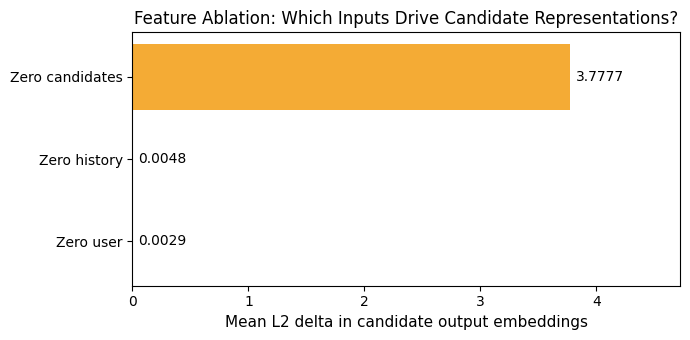

In [11]:
# Feature ablation: zero out each embedding channel, measure output delta at candidate positions
# Tells us which inputs the model actually routes information through.

def run(seq, label):
    out = transformed.apply(params_rand, rng_apply, seq, pad_mask, candidate_start_offset=cso)
    return out.embeddings[:, cso:, :]  # [B, C, D] — candidate outputs only

baseline = run(seq_emb_jax, 'baseline')

# Build ablated sequences — each zeros out one segment of the input
zeros = jnp.zeros_like

ablations = {
    'Zero user':    jnp.concatenate([zeros(seq_emb_jax[:, :1, :]),      seq_emb_jax[:, 1:, :]],   axis=1),
    'Zero history': jnp.concatenate([seq_emb_jax[:, :1, :],  zeros(seq_emb_jax[:, 1:cso, :]),  seq_emb_jax[:, cso:, :]], axis=1),
    'Zero candidates': jnp.concatenate([seq_emb_jax[:, :cso, :], zeros(seq_emb_jax[:, cso:, :])], axis=1),
}

deltas = {}
for name, seq in ablations.items():
    ablated = run(seq, name)
    deltas[name] = float(jnp.mean(jnp.linalg.norm(baseline - ablated, axis=-1)))

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#3498db', '#e74c3c', '#f39c12']
bars = ax.barh(list(deltas.keys()), list(deltas.values()), color=colors, alpha=0.85)
ax.bar_label(bars, fmt='%.4f', padding=4, fontsize=10)
ax.set_xlabel('Mean L2 delta in candidate output embeddings', fontsize=11)
ax.set_title('Feature Ablation: Which Inputs Drive Candidate Representations?', fontsize=12)
ax.set_xlim(0, max(deltas.values()) * 1.25)
plt.tight_layout()
plt.show()

## conclusions

### 1. candidates are scored purely from user+history context

The context block (Region 2) ensures every candidate receives the **complete** user+history prefix as input to the attention mechanism. Candidates don't need to be placed at a specific position relative to history to get full context.

### 2. permutation invariance — no candidate can poison another's score

The experiment in Cell 8 confirms it: C1's attention row is **bit-for-bit identical** regardless of how C2 and C3 are ordered in the sequence. Because positions 4 and 5 are masked to $-\infty$ before softmax, they contribute exactly 0 to C1's output. This is the core isolation guarantee.

### 3. causal masking in the prefix preserves history ordering

The upper-left causal block (Region 1) means later history tokens can attend to earlier ones but not vice-versa. This captures temporal ordering of the user's interaction history, the same way language models are pretrained.

### 4. the mask is a lightweight structural change

The construction is elegant: start from a standard causal mask, zero out the bottom-right candidate-to-candidate block, then restore only the diagonal. No new parameters — just a change to which positions can communicate.